In [13]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import json
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from omegaconf import OmegaConf
from tqdm.auto import tqdm

from model import GraphTrajectoryLM
from tokenizer_utils import load_tokenizer

# ── Configuration ────────────────────────────────────────────────────────────
# CHECKPOINT_PATH = "postrain_checkpoints-uniform-all-connected-more-trajectories/postrain_step_4500.pt"
CHECKPOINT_PATH = "checkpoints_posttrain/postrain_step_8000.pt"
#CHECKPOINT_PATH = "checkpoints/epoch-epoch=02-val_loss-val/loss=1.5257.ckpt"
#CHECKPOINT_PATH = "postrain_checkpoints-uniform-all-connected/postrain_step_1000.pt"
#CHECKPOINT_PATH = "postrain_checkpoints/postrain_final.pt"
#CHECKPOINT_PATH = "checkpoints/last-v7.ckpt"
# CHECKPOINT_PATH = "checkpoints_pretrain_only/last.ckpt"
#TOKENIZER_DIR = "data_output_large_critical_rw_directed_2/tokenizer"
#GRAPH_PATH = "data_output_large_critical_rw_directed_2/graph.json"
TOKENIZER_DIR = "data_output_more_trajectories/tokenizer"
GRAPH_PATH = "data_output_more_trajectories/graph.json"
CONFIG_PATH = "conf/config.yaml"

M = 50             # number of (u, v) pairs per distance
NUM_ATTEMPTS = 1   # attempts per pair
TEMPERATURE = 0.8
TOP_K = 20
MAX_NEW_TOKENS = 80
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(SEED)
torch.manual_seed(SEED)

In [14]:
# ── Load tokenizer, model, graph ─────────────────────────────────────────────
tokenizer = load_tokenizer(TOKENIZER_DIR)
cfg = OmegaConf.load(CONFIG_PATH)

model = GraphTrajectoryLM(
    vocab_size=tokenizer.vocab_size,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
    model_config=cfg.model,
    train_config=cfg.train,
)
ckpt = torch.load(CHECKPOINT_PATH, map_location="cuda", weights_only=False)

if "state_dict" in ckpt:
    model.load_state_dict(ckpt["state_dict"])
elif "model_state_dict" in ckpt:
    model.model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)

del ckpt
model.eval()
model.to(DEVICE)
print(f"Model loaded on {DEVICE}  |  vocab size: {tokenizer.vocab_size}")

with open(GRAPH_PATH) as f:
    graph_data = json.load(f)

directed = graph_data.get("directed", False)
G = nx.DiGraph() if directed else nx.Graph()
for node, neighbors in graph_data["adjacency"].items():
    for nb in neighbors:
        G.add_edge(int(node), int(nb))

kind = "directed" if directed else "undirected"
component = "weakly connected" if directed else "connected"
print(f"Graph ({kind}, {component} component): "
      f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Training max path length: {cfg.data.max_path_length}")
if directed:
    dead_ends = [n for n in G.nodes() if G.out_degree(n) == 0]
    print(f"Dead-end nodes (no outgoing edges): {len(dead_ends)}")

Model loaded on cuda  |  vocab size: 7944
Graph (directed, weakly connected component): 7939 nodes, 9559 edges
Training max path length: 10
Dead-end nodes (no outgoing edges): 2018


In [15]:
# ── Build distance-indexed pair buckets ──────────────────────────────────────
# For large graphs, computing all-pairs shortest paths is expensive.
# Instead, sample source nodes and bucket their reachable targets by distance.
# For directed graphs with weakly connected components, not every (u, v) pair
# is reachable via directed edges.  We only evaluate reachable pairs.

nodes = list(G.nodes())
pairs_by_dist: dict[int, list[tuple[int, int]]] = defaultdict(list)

SAMPLE_SOURCES = min(500, len(nodes))
source_sample = random.sample(nodes, SAMPLE_SOURCES)

total_reachable = 0
total_possible = SAMPLE_SOURCES * (len(nodes) - 1)

for src in tqdm(source_sample, desc="Computing shortest paths from sampled sources"):
    lengths = nx.single_source_shortest_path_length(G, src)
    for tgt, d in lengths.items():
        if tgt != src:
            pairs_by_dist[d].append((src, tgt))
            total_reachable += 1

max_dist = max(pairs_by_dist.keys())
print(f"Max distance found: {max_dist}")
print(f"Training max path length: {cfg.data.max_path_length}")

if directed:
    reachability_pct = total_reachable / total_possible * 100 if total_possible else 0
    print(f"\nDirected graph reachability: {total_reachable:,}/{total_possible:,} "
          f"sampled pairs are reachable ({reachability_pct:.1f}%)")

print(f"\nPairs available per distance:")
for d in sorted(pairs_by_dist.keys()):
    print(f"  d={d:>2d}: {len(pairs_by_dist[d]):>7,} pairs")

Computing shortest paths from sampled sources: 100%|██████████| 500/500 [00:00<00:00, 19455.18it/s]

Max distance found: 85
Training max path length: 10

Directed graph reachability: 43,756/3,969,000 sampled pairs are reachable (1.1%)

Pairs available per distance:
  d= 1:     603 pairs
  d= 2:     593 pairs
  d= 3:     649 pairs
  d= 4:     662 pairs
  d= 5:     677 pairs
  d= 6:     727 pairs
  d= 7:     734 pairs
  d= 8:     709 pairs
  d= 9:     723 pairs
  d=10:     732 pairs
  d=11:     709 pairs
  d=12:     712 pairs
  d=13:     716 pairs
  d=14:     715 pairs
  d=15:     757 pairs
  d=16:     808 pairs
  d=17:     813 pairs
  d=18:     820 pairs
  d=19:     835 pairs
  d=20:     810 pairs
  d=21:     816 pairs
  d=22:     789 pairs
  d=23:     809 pairs
  d=24:     806 pairs
  d=25:     884 pairs
  d=26:     933 pairs
  d=27:   1,060 pairs
  d=28:   1,029 pairs
  d=29:   1,046 pairs
  d=30:     999 pairs
  d=31:   1,024 pairs
  d=32:     996 pairs
  d=33:   1,005 pairs
  d=34:     966 pairs
  d=35:     979 pairs
  d=36:     904 pairs
  d=37:     930 pairs
  d=38:     850 pairs

In [ ]:
# ── Inference helpers ─────────────────────────────────────────────────────────

@torch.no_grad()
def generate_trajectory(start_node: int, goal_node: int) -> list[str]:
    """Autoregressively sample a trajectory. Returns the generated path tokens."""
    prompt = f"<start_goal> {start_node} {goal_node} <end_goal>"
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)

    eos_id = tokenizer.eos_token_id
    pad_id = tokenizer.pad_token_id

    generated = input_ids
    for _ in range(MAX_NEW_TOKENS):
        logits = model.model(input_ids=generated).logits[:, -1, :] / TEMPERATURE
        logits[:, pad_id] = -float("inf")

        if TOP_K > 0:
            topk_vals, _ = torch.topk(logits, TOP_K)
            logits[logits < topk_vals[:, -1:]] = -float("inf")

        next_token = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)
        generated = torch.cat([generated, next_token], dim=-1)
        if next_token.item() == eos_id:
            break

    path_tokens = tokenizer.decode(generated[0, input_ids.shape[1]:], skip_special_tokens=True).split()
    return path_tokens


def is_valid_and_reaches_goal(start: int, goal: int, path_tokens: list[str]) -> bool:
    """True iff the path is a valid walk in G from start that ends at goal."""
    try:
        path_tokens_temp = []
        for t in path_tokens:
            if t == "<eos>":
                break
            path_tokens_temp.append(int(t))
            if int(t) == goal:
                break
        path_nodes = path_tokens_temp
    except ValueError:
        return False
    if not path_nodes or path_nodes[0] != start or path_nodes[-1] != goal:
        return False
    return all(G.has_edge(path_nodes[i], path_nodes[i + 1]) for i in range(len(path_nodes) - 1))

In [17]:
# ── Run evaluation ────────────────────────────────────────────────────────────
results: dict[int, dict] = {}  # dist -> {successes, total}
dist_max = 30
for dist in tqdm(sorted(pairs_by_dist.keys()), desc="Evaluating distances"):
    if dist > dist_max:
        break

    pool = pairs_by_dist[dist]
    selected = random.sample(pool, min(M, len(pool)))
    successes = 0

    for u, v in tqdm(selected, desc=f"  d={dist}", leave=False):
        solved = False
        for _ in range(NUM_ATTEMPTS):
            path_tokens = generate_trajectory(u, v)
            if is_valid_and_reaches_goal(u, v, path_tokens):
                solved = True
                break
        if solved:
            successes += 1

    results[dist] = {"successes": successes, "total": len(selected)}
    acc = successes / len(selected) * 100
    print(f"  d={dist:>2d}:  {successes}/{len(selected)}  ({acc:.1f}%)")

Evaluating distances:   1%|          | 1/85 [01:05<1:31:03, 65.04s/it]

  d= 1:  0/50  (0.0%)


Evaluating distances:   2%|▏         | 2/85 [02:10<1:30:37, 65.51s/it]

  d= 2:  0/50  (0.0%)


Evaluating distances:   4%|▎         | 3/85 [03:17<1:30:02, 65.88s/it]

...

  d=28:  0/50  (0.0%)


Evaluating distances:  34%|███▍      | 29/85 [31:56<1:01:46, 66.19s/it]

  d=29:  0/50  (0.0%)


Evaluating distances:  35%|███▌      | 30/85 [33:02<1:00:34, 66.09s/it]

  d=30:  0/50  (0.0%)


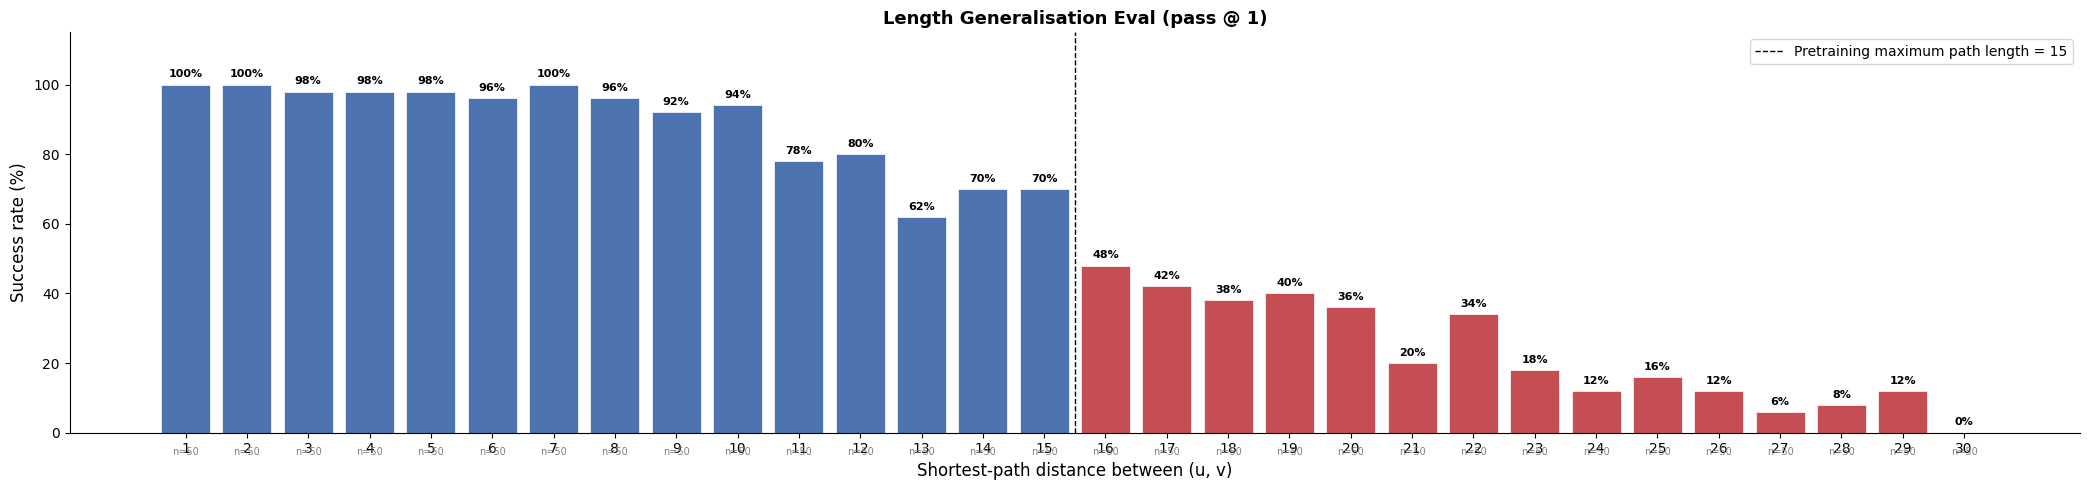


Saved plot to length_generalization_eval.png


In [12]:
# ── Plot ──────────────────────────────────────────────────────────────────────
# train_max = cfg.data.max_path_length
train_max = 15

distances = sorted(results.keys())
accuracies = [results[d]["successes"] / results[d]["total"] * 100 for d in distances]
counts = [results[d]["total"] for d in distances]

colors = ["#4c72b0" if d <= train_max else "#c44e52" for d in distances]

fig, ax = plt.subplots(figsize=(max(10, len(distances) * 0.7), 5))
bars = ax.bar(distances, accuracies, color=colors, edgecolor="white", linewidth=0.5)

for bar, acc, n in zip(bars, accuracies, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{acc:.0f}%",
        ha="center", va="bottom", fontsize=8, fontweight="bold",
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        -4,
        f"n={n}",
        ha="center", va="top", fontsize=7, color="gray",
    )

ax.axvline(x=train_max + 0.5, color="black", linestyle="--", linewidth=1, label=f"Pretraining maximum path length = {train_max}")

ax.set_xlabel("Shortest-path distance between (u, v)", fontsize=12)
ax.set_ylabel("Success rate (%)", fontsize=12)
ax.set_title(
    f"Length Generalisation Eval (pass @ {NUM_ATTEMPTS})",
    fontsize=13, fontweight="bold",
)
ax.set_xticks(distances)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("length_generalization_eval.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved plot to length_generalization_eval.png")

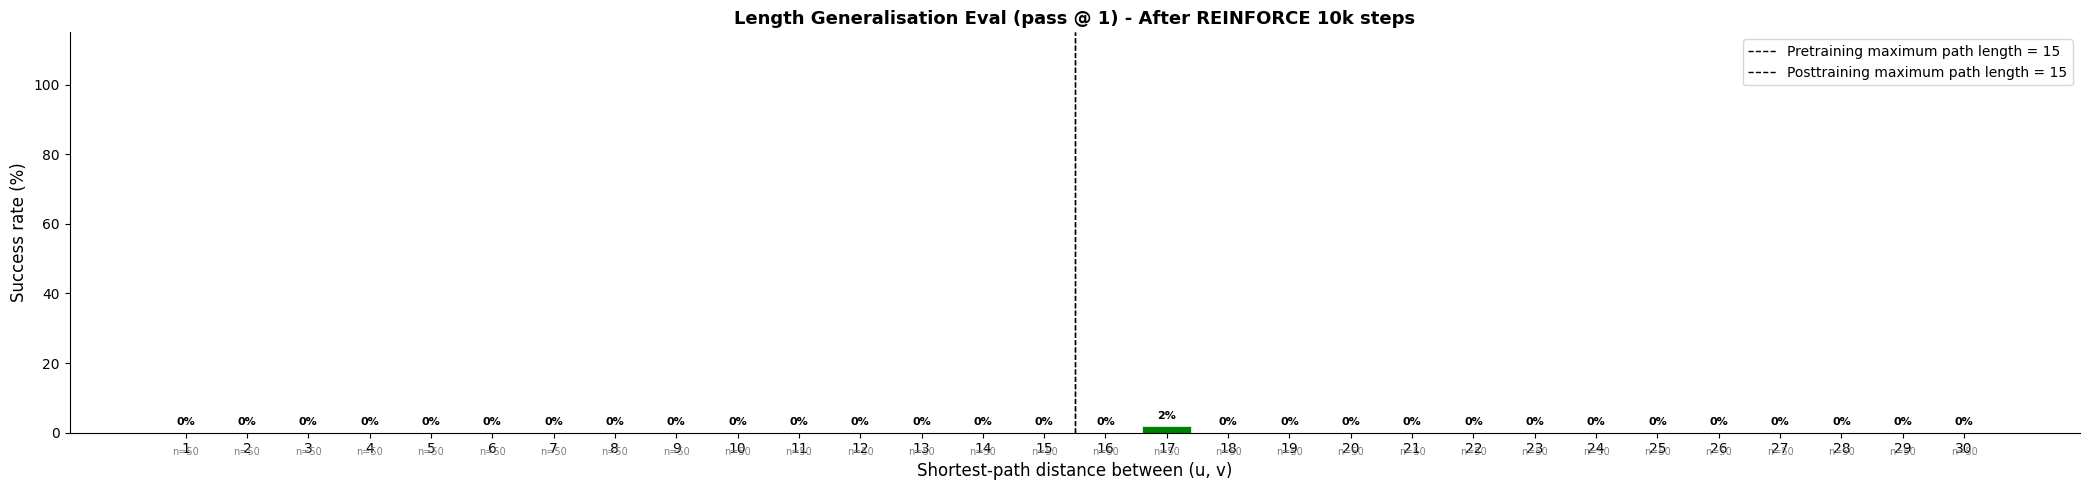


Saved plot to length_generalization_eval_posttrain.png


In [18]:
# ── Plot ──────────────────────────────────────────────────────────────────────
# train_max = cfg.data.max_path_length
train_max = 15
posttrain_max = 15

distances = sorted(results.keys())
accuracies = [results[d]["successes"] / results[d]["total"] * 100 for d in distances]
counts = [results[d]["total"] for d in distances]

colors = ["#4c72b0" if d <= train_max else "#c44e52" if d <= posttrain_max else "green" for d in distances]

fig, ax = plt.subplots(figsize=(max(10, len(distances) * 0.7), 5))
bars = ax.bar(distances, accuracies, color=colors, edgecolor="white", linewidth=0.5)

for bar, acc, n in zip(bars, accuracies, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{acc:.0f}%",
        ha="center", va="bottom", fontsize=8, fontweight="bold",
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        -4,
        f"n={n}",
        ha="center", va="top", fontsize=7, color="gray",
    )

ax.axvline(x=train_max + 0.5, color="black", linestyle="--", linewidth=1, label=f"Pretraining maximum path length = {train_max}")

ax.axvline(x=posttrain_max + 0.5, color="black", linestyle="--", linewidth=1, label=f"Posttraining maximum path length = {train_max}")

ax.set_xlabel("Shortest-path distance between (u, v)", fontsize=12)
ax.set_ylabel("Success rate (%)", fontsize=12)
ax.set_title(
    f"Length Generalisation Eval (pass @ {NUM_ATTEMPTS}) - After REINFORCE 10k steps",
    fontsize=13, fontweight="bold",
)
ax.set_xticks(distances)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("length_generalization_eval_posttrain.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved plot to length_generalization_eval_posttrain.png")